In [11]:
import pandas as pd

df= pd.read_csv(r"C:\Users\user\Downloads\drug200.csv")

print(df.head())
print(df.dtypes)
print(df.shape)
print(df.isnull().sum())
unique_values = {col: df[col].unique() for col in df.columns}
unique_values

   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY
Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object
(200, 6)
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


{'Age': array([23, 47, 28, 61, 22, 49, 41, 60, 43, 34, 74, 50, 16, 69, 32, 57, 63,
        48, 33, 31, 39, 45, 18, 65, 53, 46, 15, 73, 58, 66, 37, 68, 67, 62,
        24, 26, 40, 38, 29, 17, 54, 70, 36, 19, 64, 59, 51, 42, 56, 20, 72,
        35, 52, 55, 30, 21, 25], dtype=int64),
 'Sex': array(['F', 'M'], dtype=object),
 'BP': array(['HIGH', 'LOW', 'NORMAL'], dtype=object),
 'Cholesterol': array(['HIGH', 'NORMAL'], dtype=object),
 'Na_to_K': array([25.355, 13.093, 10.114,  7.798, 18.043,  8.607, 16.275, 11.037,
        15.171, 19.368, 11.767, 19.199, 15.376, 20.942, 12.703, 15.516,
        11.455, 13.972,  7.298, 25.974, 19.128, 25.917, 30.568, 15.036,
        33.486, 18.809, 30.366,  9.381, 22.697, 17.951,  8.75 ,  9.567,
        11.014, 31.876, 14.133,  7.285,  9.445, 13.938,  9.709,  9.084,
        19.221, 14.239, 15.79 , 12.26 , 12.295,  8.107, 13.091, 10.291,
        31.686, 19.796, 19.416, 10.898, 27.183, 18.457, 10.189, 14.16 ,
        11.34 , 27.826, 10.091, 18.703, 29.875,  9

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

categorical_cols = ['Sex', 'BP', 'Cholesterol', 'Drug']
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

X = df.drop('Drug', axis=1)  
y = df['Drug']              

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

cols_to_scale = ['Sex', 'BP', 'Cholesterol']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Decision Tree Accuracy: {acc:.2f}")


Decision Tree Accuracy: 1.00


In [41]:
train_acc = clf.score(X_train_scaled, y_train)
test_acc = clf.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")


Train Accuracy: 1.00
Test Accuracy: 1.00


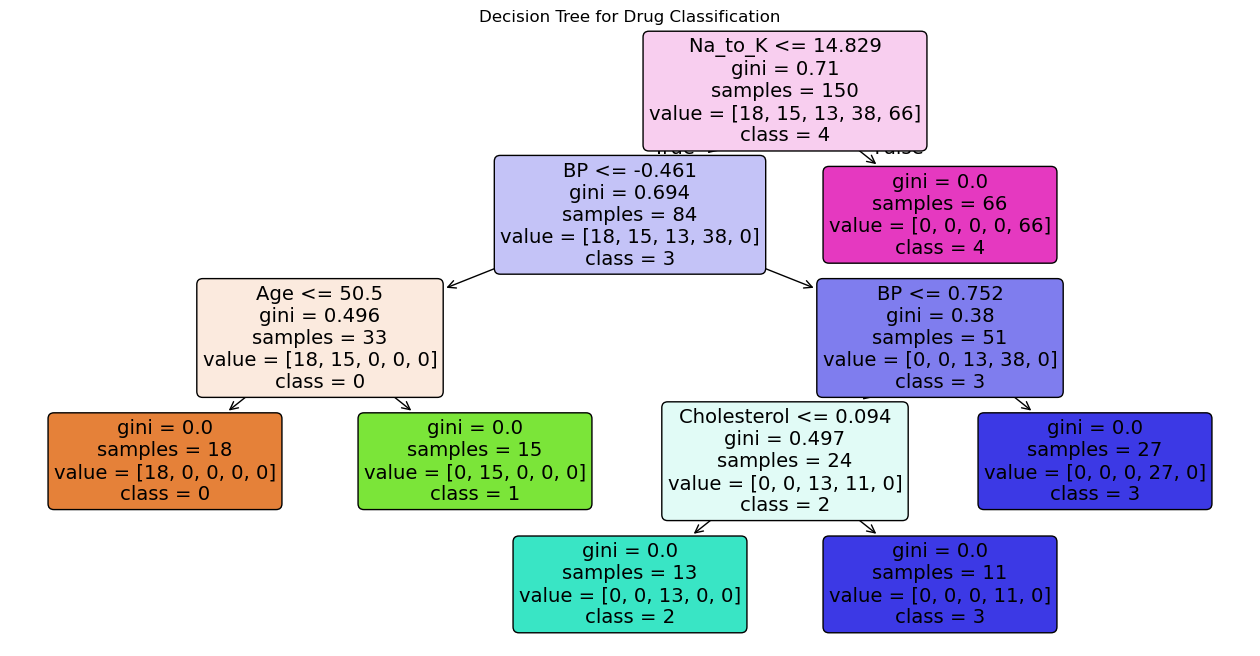

In [33]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=[str(cls) for cls in clf.classes_],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Drug Classification")
plt.show()


In [49]:
scores = cross_val_score(clf, X, y, cv=10)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())


Cross Validation Scores: [1.   1.   1.   1.   1.   1.   1.   0.95 0.95 1.  ]
Average CV Score: 0.99
